In [201]:
#################################
## 현재 전체 항적 패턴묘사 보고서 ##
#################################
# !{sys.executable} -m pip install datashader

In [6]:
# 1. 기본 시스템 및 데이터 처리
import os
import sys
import warnings
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from getpass import getpass
import json
import time

# 2. 지리 정보 및 기하학적 처리 (GIS)
import shapely as shp
import geopandas as gpd
from shapely.geometry import Point, LineString, Polygon, MultiPoint, box
from geopandas import GeoDataFrame, read_file
from geopy.distance import great_circle

# 3. 선박 궤적 분석 (MovingPandas)
import movingpandas as mpd

# 4. 머신러닝 및 데이터 분석
from sklearn.cluster import DBSCAN

# 5. 시각화 (Matplotlib & HoloViews/hvPlot)
import matplotlib.pyplot as plt
import hvplot.pandas
from holoviews import opts, dim, Layout 

# 6. 경고 메시지 무시 설정
warnings.simplefilter("ignore")

# (선택 사항) 커스텀 모듈 경로 추가
sys.path.append("..")


In [2]:
## hvplot 셋업
warnings.filterwarnings("ignore")

plot_defaults = {"linewidth": 5, "capstyle": "round", "figsize": (9, 3), "legend": True}
opts.defaults(opts.Overlay(active_tools=["wheel_zoom"]))
hvplot_defaults = {
    "tiles": "CartoLight",
    "frame_height": 320,
    "frame_width": 320,
    "cmap": "Viridis",
    "colorbar": True,
}

In [9]:
## 데이터 불러오기 및 한반도 남해 지역 데이터 필터링
start = time.time()
ais_df = pd.read_csv("./기상데이터/Sample01_AIS_new_category_final.csv") 

min_lon, max_lon = 125.678, 131.229
max_lat = 36.001

ais_df_filtered = ais_df[
    (ais_df['longitude'] >= min_lon) & (ais_df['longitude'] <= max_lon) & (ais_df['latitude'] <= max_lat)
]


ais = ais_df_filtered

# if filtering by "timestamp" 
start_time = "2022-12-01 00:00:00"
end_time = "2022-12-02 23:50:00"
time_diff = pd.to_datetime(end_time) - pd.to_datetime(start_time)

# Dataframe을 GeoDataFrame으로 전환
ais = gpd.GeoDataFrame(
    # compressed_once_df,
    ais,
    geometry = gpd.points_from_xy(ais.longitude, ais.latitude),
    crs="EPSG:4326"
)

#시간 인덱스 설정 및 속도 0이상인 항적만 추출
ais['t'] = pd.to_datetime(ais['timestamp'], format='mixed', utc=True)
ais = ais.set_index('t')
ais = ais[(ais['timestamp']>= start_time)&(ais['timestamp'] <= end_time)]
ais = ais[ais.speed>0]
print(f"소요시간: {time.time()-start}초")


소요시간: 7.0370659828186035초


In [10]:
#####################################
### "LOCAL" VLLM MODEL Initiation ###
#####################################
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

#vllm starter 
vllm = ChatOpenAI(
    api_key = "ai",
    base_url = "http://192.168.0.110:8000/v1", # for A6000
    # base_url = "http://192.168.0.108:8000/v1", # for A5000
    model = "openai/gpt-oss-20b",
    # model = "unsloth/Meta-Llama-3.1-70B-Instruct-bnb-4bit"
    # model = "unsloth/gemma-3-27b-it-bnb-4bit",
    # model="meta-llama/Llama-3.1-8B-Instruct",
    # model="mistralai/Mistral-7B-Instruct-v0.3",
    # model="Qwen/Qwen2-7B-Instruct",
    # model="unsloth/Mistral-Small-24B-Instruct-2501-bnb-4bit",
    # model = "unsloth/Qwen3-14B-bnb-4bit",
    # model = "unsloth/gemma-3-12b-it-bnb-4bit",
    # model = "unsloth/gemma-2-9b-it-bnb-4bit",
    max_tokens = 6000,
    temperature = 0.2
)

In [11]:
# 전체패턴 요약을 위한 프롬프트 템플릿
def prompt_template_trajs_overall(start_time, end_time, time_diff,
                                  clusters_data, speed_data,
                                  direction_flow_data,
                                  trajs_flow_data, shiptype_data):
    return f"""
    # Role
    당신은 대한민국 해양수산부 소속의 '해상교통관제(VTS) 데이터 분석 전문가' 입니다.
    제공된 통계 데이터를 바탕으로 해상 교통 흐름의 전체적인 패턴을 분석하고 현재 선박 운항 현황을 묘사해 주세요.  

    #Input Data (Summarized Statistics)
    1. [분석 대상 시간]:
    - 시작 시점: {start_time}
    - 종료 시점: {end_time}
    - (약 {time_diff} 동안의 데이터 집계 결과)
    2. [구역별 밀집 현황]: 
    {clusters_data}
    3. [구역별 선박 이동 속도 요약]:
    {speed_data}
    4. [주요 교통 흐름 (방향별 이동 현황)]:
    {direction_flow_data}
    5. [구역 간 주요 유동성(OD Flow) 현황]: 
    {trajs_flow_data}
    6. [선박 유형별 요약]:
    {shiptype_data}
    

    # Context & Rules
    - cluster_data에서 'total_stay_index'가 높을수록 해당 구역에 더 많은 항적이 밀집되어 있음을 의미합니다. 
    - speed_data에서 'mean'은 해상구역별 평균속도를 의미합니다. 평균속도가 클수록 선박이 해당 구간에서 더 빨리 이동하고 있음을 의미합니다. 
    - traj_flow_data에서 'weight'가 높을수록 해당 경로(origin_zone -> dest_zone)는 주 간선 항로(Main Route)임을 의미합니다.
    - 선박 유형별로 사용자가 쉽게 알아볼 수 있도록 테이블로 정리해줘. 데이터에 근거하여 가장 높은 비중을 차지하는 상위 3개 함종이 무엇인지 간단하게 설명해주고 상상이나 추측성 발언은 완전히 삼가해줘.  
    - 보고서에는 traj_stay_index 값 혹은 weight값을 포함시키지 않아도 되. 이 값이 높다는건 항적이나 항로가 많이 밀집되어 있다는 의미정도로만 해석하면되.  
    - 전문가적 통찰은 포함하되, 모든 분석은 반드시 제공된 데이터의 수치에 근거해야 합니다. 

    # Mission
    1. **[분석 대상 시간]**: 1번 데이터를 활용하여 분석 대상 시간을 자연스러운 자연어로 묘사하세요. 
    2. **[밀집 구역 분석(Data Dashboard Fig 1 참고)]**: 2번 데이터를 활용하여 'total_stay_index'를 기준으로 상위 3개 핵심 해역을 선정하고, 해당 지역이 해상 교통 안전 관리 측면에서 왜 중요한지 한 문장으로 요약하세요.  
    3. **[구간별 속도 분석(Data Dashboard Fig 1 참고)]**: 2번 데이터를 활용하여 각 구역(Zone)별 선박의 평균 속도(mean) 분포를 비교하고, 대한민국 남해안 해역의 공간적 특성에 따른 속도 변화 패턴을 분석하세요. 
         특히 연안과 외해, 그리고 주요 항만 주변 간의 전반적인 주요 핵심 패턴만 설명하세요.   
    4. **[이동 방향 및 흐름 분석]**: 4번 데이터를 바탕으로 현재 가장 지배적인 이동 방향을 식별하고, 해당 흐름의 규모 및 이동 속도의 특성을 분석하세요.  
    4. **[주요 항로 패턴(Data Dashboard Fig 1 참고)]**: 5번 데이터를 활용하여 'weight' 기준 상위 5개 항로를 분석하여 대한민국 남해안의 주요 항로 패턴이 어떻게 형성되어 있는지 설명하세요. 
    5. **[선박 유형 요약(Data Dashboard Table 1 참고)]**: 2번 데이터를 활용하여 선박 유형별 카운트 테이블에 대해 간단하게 설명하세요.  
    6. **[종합 결론]**:  현재 데이터상에서 나타나는 가장 두드러진 해상 교통 특징을 기술하세요. 

    # Tone & Manner
    - 간결하게 핵심 내용 요약.
    - 전문 용어(병목 구간, 간선 항로, 트래픽 밀도 등)를 적절히 활용.
    """

In [12]:
# Local LLM call 함수
def execute_llm_prompt(model, prompt_input):
    # LangChain's chat models take a list of message objects
    prompt_response = model.invoke(
        [
            HumanMessage(content=prompt_input)
        ],
        temperature = 0.1
    )
    # the following if statement is for preprocessing answers from QWEN since it contains <think> section by defulat. 
    if "<think>" in prompt_response.content:
        prompt_response = removing_think_from_qwen(prompt_response)
        return prompt_response

    else:
        return prompt_response.content

In [13]:
##########################################################
## DBSCAN Clustering & OD(origin-destination) Flow 분석 ##
##########################################################

# cluster 분석을 위한 전처리
MIN_LENGTH = 1000 # in meters; 1000m 이상인 항적들만 추출
TRIP_ID = 'mmsi'
traj_collection = mpd.TrajectoryCollection(ais, TRIP_ID, min_length=MIN_LENGTH)
trips = mpd.ObservationGapSplitter(traj_collection).split(gap=timedelta(minutes=120)) #60분 이산 정박한 경우 trajectory 분할

print("Finished creating {} trajectories".format(len(traj_collection)))
print("Extracted {} individual trips from {} continuous vessel tracks".format(len(trips), len(traj_collection)))

Finished creating 60 trajectories
Extracted 92 individual trips from 60 continuous vessel tracks


In [14]:
# cluster 분석을 위한 기본 파라미터값 정의
KMS_PER_RADIAN = 6371.0088
EPSILON = 3.0 / KMS_PER_RADIAN 

In [15]:
# 항적 통합 및 단순화
start = time.time()
aggregator = mpd.TrajectoryCollectionAggregator(trips, max_distance=100000, min_distance=2000, min_stop_duration=timedelta(minutes=120))

flows = aggregator.get_flows_gdf()
clusters = aggregator.get_clusters_gdf()
print(f"소요시간: {time.time()-start}초")

소요시간: 12.040058374404907초


In [16]:
# 결과 시각화
start = time.time()

flows_plot = flows.hvplot(title='Generalized aggregated trajectories', 
              geo=True, hover_cols=['weight'], 
              line_width='weight', alpha=0.5, 
              color='#1f77b3', tiles='OSM', frame_height=300, 
              frame_width=400)
cluster_plot = clusters.hvplot(geo=True, color='red', size='n') 

flows_plot * cluster_plot 
print(f"소요시간: {time.time()-start}초")

소요시간: 1.4527015686035156초


In [17]:
################################################
### LLM 활용을 통한 항적 패턴 요약을 위한 전처리 ###
################################################

### 전체 항적 패턴 요약에 사용할 해상 구역 정의
zone_configs = {
    # --- [Layer 1: 북부 연안 및 울산] Lat: 34.70 ~ 36.00 (일부 34.40 시작) ---
    'Zone_16':   [125.00, 34.40, 125.50, 36.00, '서해 남부 외해'],
    'Zone_5':    [125.50, 34.40, 126.60, 36.00, '목포-신안 해역'],
    'Zone_12':   [126.60, 34.40, 127.60, 36.00, '고흥-완도 연안'],
    'Zone_3':    [127.60, 34.70, 128.00, 36.00, '광양-여수 해역'],
    'Zone_4':    [128.00, 34.70, 128.30, 36.00, '남해 중앙 연안'],
    'Zone_2':    [128.30, 34.70, 128.70, 36.00, '거제-통영 해역'],
    'Zone_1':    [128.70, 34.70, 129.30, 36.00, '부산-가덕 해역'],
    'Zone_18':   [129.30, 34.70, 130.50, 36.00, '부산외항-울산남부'], # 부산 동쪽 빈틈 메움
    'Zone_14':   [130.50, 35.15, 132.50, 36.00, '울산-포항 해역'],
    
    # --- [Layer 2: 중단 외해 및 대한해협] Lat: 33.80 ~ 34.70 ---
    'Zone_7':    [125.00, 33.00, 126.20, 34.40, '서남해 외해'],
    'Zone_8':    [126.20, 33.80, 127.60, 34.40, '제주-육지 교차로 해역'],
    'Zone_9_1':  [127.60, 33.80, 128.30, 34.70, '여수-통영 외해'],
    'Zone_9_2':  [128.30, 33.80, 128.70, 34.70, '거제-가덕 외해'],
    'Zone_9_3':  [128.70, 33.80, 129.30, 34.70, '부산-대마도 입구 해역'], # 부산 하단 빈틈 메움
    'Zone_15_1': [129.30, 33.80, 130.50, 34.70, '대마도 남서 해역'],
    'Zone_17':   [130.50, 33.80, 131.50, 34.25, '시모노세키-기타큐슈 해역'],
    'Zone_15_2': [130.50, 34.25, 131.50, 35.15, '대마도 북동 해역'],
    
    # --- [Layer 3: 제주 및 일본 연안] Lat: 33.00 ~ 33.80 ---
    'Zone_6':    [126.20, 33.40, 126.90, 33.80, '제주 북부 연안'],
    'Zone_13':   [126.20, 33.00, 126.90, 33.40, '제주 남부 연안'],
    'Zone_11':   [126.90, 33.00, 129.50, 33.80, '제주 남동부 해역'],
    'Zone_15_3': [129.50, 33.00, 131.00, 33.80, '이키-후쿠오카 연안'],
    'Zone_15_4': [131.00, 33.00, 132.50, 35.15, '일본 가이요 외해'],
    
    # --- [Layer 4: 최남단 원거리] Lat: 31.00 ~ 33.00 ---
    'Zone_10':   [125.00, 31.00, 132.50, 33.00, '원거리 국제공해']
}

start = time.time()

polygons = []
ids = []
names = []

for zid, val in zone_configs.items():
    polygons.append(box(val[0], val[1], val[2], val[3]))
    ids.append(zid)
    names.append(val[4])

zones_gdf = gpd.GeoDataFrame({'zone_id': ids, 'name': names}, 
                             geometry=polygons, crs="EPSG:4326")
print(f"소요시간: {time.time()-start}초")

소요시간: 0.023997068405151367초


In [18]:
####################################################################################
### Spatial Join을 활용하여 cluster와 flow, & speed 데이터에 해상구역 이름 속성값 부여 ##
start = time.time()

# 1. 클러스터 포인트에 Zone이름 부여
named_clusters = gpd.sjoin(clusters, zones_gdf, how="inner", predicate="within")

# 2. Flow(Line)의 시작점과 끝점에 Zone 이름 부여
# Line의 첫 번째 점과 마지막 점을  추출하여 각각 Join
flows['start_point'] = flows.geometry.apply(lambda x: x.coords[0])
flows['end_point'] = flows.geometry.apply(lambda x: x.coords[-1])

# 시작점/끝점용 임시 gdf 생성 후 Spatial Join
start_gdf = gpd.GeoDataFrame(flows, geometry=gpd.points_from_xy([p[0] for p in flows.start_point], [p[1] for p in flows.start_point]), crs=4326)
end_gdf = gpd.GeoDataFrame(flows, geometry=gpd.points_from_xy([p[0] for p in flows.end_point], [p[1] for p in flows.end_point]), crs=4326)



start_join = gpd.sjoin(start_gdf, zones_gdf, how="left")
start_join = start_join[~start_join.index.duplicated(keep='first')]
flows['origin_zone'] = start_join['name']


end_join = gpd.sjoin(end_gdf, zones_gdf, how="left")
end_join = end_join[~end_join.index.duplicated(keep='first')]
flows['dest_zone'] = end_join['name']

print(f"소요시간: {time.time()-start}초")

소요시간: 0.05241847038269043초


In [19]:
start = time.time()


# spatial join된 named_cluster를 aggregation을 통한 2차 요약
cluster_summary = named_clusters.groupby('name')['n'].agg(['count', 'sum']).rename(columns={'count':'stop_count', 'sum':'total_stay_index'}).reset_index()
cluster_summary = cluster_summary.sort_values(by='total_stay_index', ascending=False)

# spatial join된 flows를 aggregation을 통한 2차 요약
flow_summary = flows.groupby(['origin_zone', 'dest_zone'])['weight'].sum().reset_index()
flow_summary = flow_summary.sort_values(by='weight', ascending=False).head(13) # 상위 10개 항로

# LLM에 전달하기 위해 json형식으로 변환
import json

data_dict_cluster = cluster_summary.to_dict(orient="records")
clusters_data = json.dumps(data_dict_cluster, ensure_ascii=False, indent=4)

data_dict_flow = flow_summary.to_dict(orient='records')
trajs_flow_data = json.dumps(data_dict_flow, ensure_ascii=False, indent=4)

print(f"소요시간: {time.time()-start}초")

소요시간: 0.04807686805725098초


In [20]:
# 1) 속도 묘사를 위한 데이터 전처리 suing SPATIAL JOIUN
# trajectory collection에서 모든 포인트 추출

start = time.time()

# sjoin을 통해 포인트가 속한 구역정보를 결합
joined_gdf = gpd.sjoin(ais, zones_gdf, how='left', predicate='within')
# 결합 후 구역에 속하지 않은 데이터 NaN 됨
joined_gdf = joined_gdf.dropna(subset=['name'])

# 구역별 속도 통계 산출
zone_speed_stats = joined_gdf.groupby('name')['speed'].agg(['mean', 'max', 'count']).reset_index()

# 시각화용 데이터 병합 zone 데이터 + 속도 통계
zones_plot_data = zones_gdf.merge(zone_speed_stats, on='name')

# LLM에 전달하기 위해 json으로 변환
data_dict_speed = zone_speed_stats.to_dict(orient="records")
speed_data = json.dumps(data_dict_speed, ensure_ascii=False, indent=4)
print(f"소요시간: {time.time()-start}초")

소요시간: 0.050528764724731445초


소요시간: 0.2824819087982178초


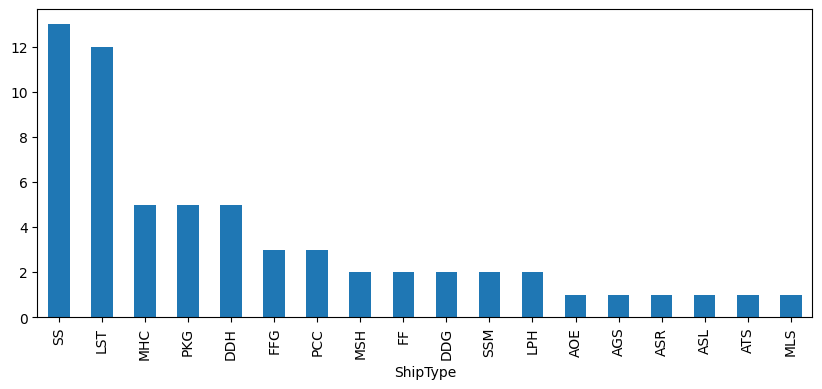

In [21]:
start = time.time()
# ShipType별 선박 Count 및 시각화
shiptype_count_summary = ais.groupby('ShipType')['mmsi'].nunique().sort_values(ascending=False)

#LLM을 위한 전처리
data_dict_shiptype = shiptype_count_summary.to_dict()
shiptype_data = json.dumps(data_dict_shiptype, ensure_ascii=False, indent=4)

#for Dashboard 시각화
shiptype_count_summary.plot(kind="bar", figsize=(10,4))
print(f"소요시간: {time.time()-start}초")

In [22]:
#####################################################
# 평균 Direction(향) 분석을 통한 지배적인 교통흐름 파악 #
#####################################################
def get_direction_analysis(df):
    # '이동' 중인 선박만 추출
    cruising_raw = df[df['status'] != '정박/대기'].copy()
    
    cruising = cruising_raw.groupby('mmsi').agg({
        'first_course': 'last',
        'avg_speed': 'mean'}).reset_index()
    
    if cruising.empty:
        return "현재 이동 중인 주요 선박 흐름 없음"

    # --- 1. 방향 그룹화 (Binning) ---
    # 0~360도를 8방위로 나누기 
    # 북쪽(North)은 337.5~22.5도 사이이므로, 계산 편의를 위해 범위 조절.
    bins = [-0.1, 22.5, 67.5, 112.5, 157.5, 202.5, 247.5, 292.5, 337.5, 360.1]
    labels = ['북', '북동', '동', '남동', '남', '남서', '서', '북서', '북'] 

    cruising['direction_group'] = pd.cut(cruising['first_course'], bins=bins, labels=labels, ordered=False)
    
    # --- 2. 통계 계산 ---
    # 각 방향별 선박 수 계산 및 0인 항목 제거
    flow_counts = cruising['direction_group'].value_counts()
    flow_counts = flow_counts[flow_counts > 0]

    unique_labels = []
    for l in labels:
        if l not in unique_labels:
            unique_labels.append(l)
    
    cruising['sin'] = np.sin(np.radians(cruising['first_course']))
    cruising['cos'] = np.cos(np.radians(cruising['first_course']))
    
    agg_flow = cruising.groupby('direction_group', observed=True).agg({
        'mmsi': 'count',
        'avg_speed': 'mean',
        'sin': 'mean',
        'cos': 'mean'
    })
    
    # 텍스 요약 생성
    flow_reports = []
    
    for direction in unique_labels: 
        if direction in agg_flow.index:
            data = agg_flow.loc[direction]
            count = int(data['mmsi'])
    
            if count == 0: continue
    
            curr_avg_speed = float(data['avg_speed'])
            vec_avg = float(np.degrees(np.arctan2(data['sin'], data['cos'])) % 360)
            
            flow_reports.append({
                "direction":f"{direction}진",
                "ship_count": count,
                "average_speed_knot": round(curr_avg_speed, 1),
                "vector_course_deg": round(vec_avg, 1)
            })
    return json.dumps(flow_reports, ensure_ascii=False, indent=4)


In [23]:
## 주요 향별 묘사를 위한 데이터 전처리##
# df_summarization 
def compress_ship_data_py(df):
    # 1. 데이터 타입 변환 및 정렬
    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')
    df['course'] = pd.to_numeric(df['course'])
    df['speed'] = pd.to_numeric(df['speed'])
    df = df.sort_values(['ShipName','timestamp'])

    # 2. 변화량 및 트리거 계산
    df['prev_lon'] = df.groupby('ShipName')['longitude'].shift(1).fillna(df['longitude'])
    df['prev_lat'] = df.groupby('ShipName')['latitude'].shift(1).fillna(df['latitude'])
    df['prev_course'] = df.groupby('ShipName')['course'].shift(1).fillna(df['course'])
    df['prev_speed'] = df.groupby('ShipName')['speed'].shift(1).fillna(df['speed'])

    # 1) 위치 변화 비교
    df['pos_change'] = np.where(
        (df['longitude'].round(3) != df['prev_lon'].round(3)) | 
        (df['latitude'].round(3) != df['prev_lat'].round(3)), 1, 0
    )

    # 2) 침로 변화 비교(180도 회전 보정 포함)
    df['course_diff_raw'] = df['course'] - df['prev_course']
    df['course_diff'] = np.where(df['course_diff_raw'] > 180, df['course_diff_raw'] - 360,
                        np.where(df['course_diff_raw'] < -180, df['course_diff_raw'] + 360,
                        df['course_diff_raw']))
    df['course_change'] = np.where((df['course_diff'].abs() >= 20) & (df['speed'] >= 1.0), 1, 0)

    # 3) 속도 변화
    df['speed_diff'] = df['speed'] - df['prev_speed']
    df['speed_change'] = np.where(df['speed_diff'].abs() >= 2, 1, 0)

    # 4) 이벤트 트리거 
    df['event_trigger'] = np.where((df['pos_change'] == 1) | (df['course_change'] == 1) | (df['speed_change'] == 1), 1, 0)
    df['group_id'] = df.groupby('ShipName')['event_trigger'].cumsum()

    # 5. 그룹별 요약
    df_summarized = df.groupby(['ShipName', 'group_id']).agg(
        mmsi = ('mmsi', 'first'),
        higher_types = ('higher_types', 'first'),
        radius = ('radius','first'),
        start_time = ('timestamp', 'min'),
        end_time = ('timestamp', 'max'),
        lon = ('longitude', 'first'),
        lat = ('latitude', 'first'),
        first_course = ('course', 'first'), 
        avg_speed = ('speed', 'mean'),
        turn_val = ('course_diff', 'first'),
        accel_val = ('speed_diff', 'first')
    ).reset_index()

    # 6. 그룹 간 속도 차이 및 최종 상태 판별
    df_summarized['prev_avg_speed'] = df_summarized.groupby('ShipName')['avg_speed'].shift(1).fillna(df_summarized['avg_speed'])
    df_summarized['group_speed_diff'] = df_summarized['avg_speed'] - df_summarized['prev_avg_speed']

    def determine_status(row):
        # 1순위: 정박/대기
        if row['avg_speed'] < 1.0:
            return "정박/대기"

        # 2순위: 운항 중 상세 상태 
        # 선회 판단
        turn_desc = ""
        if abs(row['turn_val']) >= 20 and row['avg_speed'] >= 1.0:
            direction = "우선회" if row['turn_val'] > 0 else "좌선회"
            turn_desc = f"{direction}({round(abs(row['turn_val']), 1)}°)"

        # 가감속 판단
        accel_desc = ""
        if row['group_speed_diff'] >= 2:
            accel_desc = "가속"
        elif row['group_speed_diff'] < -2:
            accel_desc = "감속"

        # 기본 이동 상태
        move_desc = "이동/통과" if row['avg_speed'] >= 5.0 else "저속 운항"

        # 정보 결합 (불필요한 공백 제거)
        status_parts = [turn_desc, accel_desc, move_desc]
        return " ".join([p for p in status_parts if p != ""]).strip()

    df_summarized['status'] = df_summarized.apply(determine_status, axis=1)

    # 불필요한 중간 계산 컬럼 삭제 후 반환
    return df_summarized.drop(columns=['prev_avg_speed'])

def compress_ship_data_py_further(df):
    df['prev_status'] = df.groupby('ShipName')['status'].shift(1).fillna(df['status'])
    # 1) status 변화 비교
    df['status_change'] = np.where(
        df['status'] != df['prev_status'], 1, 0
    )
    df['group_id'] = df.groupby('ShipName')['status_change'].cumsum()
    df_summarized = df.groupby(['ShipName', 'group_id']).agg(
        mmsi = ('mmsi', 'first'),
        higher_types = ('higher_types', 'first'),
        radius = ('radius','first'),
        start_time = ('start_time', 'min'),
        end_time = ('end_time', 'max'),
        lon = ('lon', 'first'),
        lat = ('lat', 'first'),
        first_course = ('first_course', 'first'), 
        avg_speed = ('avg_speed', 'mean'),
        turn_val = ('turn_val', 'first'),
        accel_val = ('accel_val', 'first'),
        status = ('status', 'first')
    ).reset_index()
    return df_summarized

In [24]:
start = time.time()
status_sum = compress_ship_data_py(ais)
status_sum_further = compress_ship_data_py_further(status_sum)
print(f"status_sum has {status_sum.shape} & status_sum_further has {status_sum_further.shape}")
print(f"소요시간: {time.time()-start}초")

status_sum has (8069, 17) & status_sum_further has (1397, 14)
소요시간: 1.374910831451416초


In [25]:
start = time.time()
direction_flow_data = get_direction_analysis(status_sum_further)
# print(direction_flow_data)
print(f"소요시간: {time.time()-start}초")

소요시간: 0.018793344497680664초


In [29]:
print(direction_flow_data)

[
    {
        "direction": "북진",
        "ship_count": 4,
        "average_speed_knot": 8.8,
        "vector_course_deg": 5.4
    },
    {
        "direction": "북동진",
        "ship_count": 5,
        "average_speed_knot": 8.6,
        "vector_course_deg": 37.1
    },
    {
        "direction": "동진",
        "ship_count": 6,
        "average_speed_knot": 8.7,
        "vector_course_deg": 91.0
    },
    {
        "direction": "남동진",
        "ship_count": 6,
        "average_speed_knot": 10.9,
        "vector_course_deg": 145.8
    },
    {
        "direction": "남진",
        "ship_count": 6,
        "average_speed_knot": 8.4,
        "vector_course_deg": 179.1
    },
    {
        "direction": "남서진",
        "ship_count": 14,
        "average_speed_knot": 9.9,
        "vector_course_deg": 227.3
    },
    {
        "direction": "서진",
        "ship_count": 9,
        "average_speed_knot": 8.2,
        "vector_course_deg": 266.7
    },
    {
        "direction": "북서진",
        "ship_coun

In [27]:
start = time.time()
# 향 분석을 통한 주요 교통흐름 파악 시각화 for dashboard
ais["dir_class"] = ((ais["course"]-22.5)/45).round(0)
temp = ais

Layout(
    [
        temp[temp["dir_class"] == i].hvplot(
            geo=True,
            tiles="OSM",
            c="mmsi",
            cmap="Category10",
            size=3,
            width=300,
            height=300,
            title=str(int(i * 45)) + "°",
            colorbar=False,
            xlabel="",
            ylabel=""
        )
        for i in sorted(temp["dir_class"].unique())
        if i < 8
    ]
).cols(2)
print(f"소요시간: {time.time()-start}초")

소요시간: 0.1592092514038086초


In [26]:
start = time.time()

#LLM을 통한 답변 생성
major_trajs_desc = prompt_template_trajs_overall(start_time, end_time, time_diff, 
                                                 clusters_data, speed_data,
                                                 direction_flow_data,
                                                 trajs_flow_data, shiptype_data)

answer_major_trajs_desc = execute_llm_prompt(vllm, major_trajs_desc)
print(f"소요시간: {time.time()-start}초")
print(answer_major_trajs_desc)

소요시간: 27.078104972839355초
**해상교통관제(VTS) 데이터 분석 보고서**  
(2022‑12‑01 00:00:00 ~ 2022‑12‑02 23:50:00)

---

### 1. 분석 대상 시간  
- **기간**: 2022년 12월 1일 00:00 시부터 12월 2일 23:50 시까지  
- **총 관측 시간**: 1 일 23 시간 50 분 (약 47 시간)  
- **특이점**: 24‑시간 연속 관측이 아니라 10 분 간격으로 데이터가 수집된 48 시간에 해당합니다.  

---

### 2. 밀집 구역 분석 (Data Dashboard Fig 1)  
| 순위 | 구역 | total_stay_index | 해상교통 안전 관리에서의 중요성 |
|------|------|------------------|--------------------------------|
| 1 | 부산‑가덕 해역 | 113 | 가장 높은 항적 밀도로 인해 충돌 위험이 높으며, 항만 접근 통제와 선박 분산이 필수적 |
| 2 | 시모노세키‑기타큐슈 해역 | 90 | 국제 항로와 인접해 있어 선박 간 충돌·충돌 위험이 크고, 국제선 통제가 필요 |
| 3 | 여수‑통영 외해 | 89 | 지역 항만과 연결되는 주요 항로가 밀집돼 있어 선박 흐름 조절이 중요 |

> **핵심**: 상위 3개 구역은 항적 밀도가 높아 교통 혼잡·충돌 위험이 가장 크므로, VTS에서 선박 분산·속도 제한 조치를 우선적으로 적용해야 합니다.  

---

### 3. 구간별 속도 분석 (Data Dashboard Fig 1)  
- **연안(항만 주변)**  
  - **부산‑가덕 해역**: 평균 2.37 kn (가장 낮음) – 항만 접근·출항 시 속도 제한이 가장 엄격  
  - **여수‑통영 외해**: 평균 5.07 kn – 항만 접근 시 속도 제한이 존재  
- **외해(항만에서 20 km 이상)**  
  - **거제‑가덕 외해**: 평균 8.50 kn – 비교적 빠른 속도, 항로

In [28]:
## 해상 구역과 flow-cluster-speed plot 같이 전시

# 1. 공통 배경 레이어 설정 (Tiles 정의)
# zones_bg = zones_gdf.hvplot(
#     geo=True, tiles='OSM', alpha=0.15, c='name', 
#     line_color='black', line_width=1, hover_cols=['name'], 
#     legend=False, frame_height=400, frame_width=500
# )
start = time.time()
zones_plot_data['mean'] = pd.to_numeric(zones_plot_data['mean'])

# 구역  색상을 평균 속도로 구하기
zones_speed = zones_plot_data.hvplot(
    geo=True, tiles="OSM", alpha=0.45, c="mean",
    colorbar=True, clabel="Speed (knots)",
    line_color='black', line_width=1, cmap='YlOrRd', 
    hover_cols=['name', 'mean_knots'], 
    frame_height=400, frame_width=500, legend=False)

# 2. Aggregated Trajectories (MovingPandas 결과)
aggregated_chart = zones_speed * flows.hvplot(
    geo=True, hover_cols=['weight'], line_width='weight', 
    alpha=0.5, color='#1f77b3'
) * clusters.hvplot(
    geo=True, color='red', size='n'
)

# title 설정
flow_cluster_map = aggregated_chart.opts(
    title='Comparison: Aggregated OD Flows, Speed with Analysis Zones'
)
print(f"소요시간: {time.time()-start}초")
flow_cluster_map

소요시간: 0.03432774543762207초


:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]   (mean,name)
   .Path.I     :Path   [Longitude,Latitude]   (weight)
   .Points.I   :Points   [Longitude,Latitude]   (n)

In [ ]:
# 전체적인 템플릿 통합방안. 
# 0) 해당 리포팅 날짜 및 시간 (Done)
# 1) 속도 묘사 통합 (히스토 그램 통합 방안, 구간 별 요약 방안)(Done)
# 2) Higher Types별 묘사 방안 (Done)
# 3) 주요 향(direction)별 이동 패턴 묘사 (Done)
# 4) status별 선박 묘사 (in progress...)
# 5) 주요 항만 별 요약(부산항, 거제항, 울산항 등등) (in progress...)
# 6) (창수)날씨 template
# 7) (창수)기존 템플릿과 통합


# 8) if enough time, 주요 지형/지물 묘사 방안(need research)